# Knee Osteoarthritis Classification using EfficientNet-V2B3
## Baseline Model with Balanced Dataset

This notebook implements a deep learning approach to classify knee osteoarthritis severity into five grades using transfer learning with EfficientNet-V2B3. The model leverages a balanced training dataset to ensure fair representation across all severity levels, combined with CLAHE image preprocessing to enhance feature visibility in X-rays.

### Workflow Overview
- **Data**: Uses balanced training split (train_balanced) to avoid class bias
- **Preprocessing**: Standard EfficientNetV2 preprocessing only (No CLAHE) for improved X-ray contrast
- **Architecture**: EfficientNet-V2B3 with fine-tuning on all layers
- **Training**: 50 epochs (with early stopping) with class weights and validation monitoring
- **Evaluation**: Comprehensive metrics including confusion matrices and GradCAM visualizations

In [1]:
import sys
print(sys.executable)

/workspaces/fyp_experiment/.venv-4/bin/python


In [2]:
import tensorflow as tf

# Keep the GPU available and enable memory growth so TensorFlow does not
# reserve all device memory up front inside the container.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as exc:
            print(f"Could not enable memory growth for {gpu}: {exc}")

print("TF version:", tf.__version__)
print("GPUs:", gpus)

I0000 00:00:1780672515.612413   32049 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1780672519.351929   32049 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 1. Environment Setup

First, let's import all the necessary libraries for data handling, visualization, and deep learning model building.

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
import timeit
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix)
import cv2

np.random.seed(12049)

### Seed Configuration
Setting a fixed random seed ensures reproducibility of results across different runs.

In [5]:
def get_classes(data_path, classes, data):
    print(f"----{data}----")
    knee_severity={}
    count=0

    for i in range(len(classes)):
        imgs=os.listdir(os.path.join(data_path, str(i)))
        knee_severity[i]=imgs
        count+=len(imgs)

    for k, v in knee_severity.items():
        print(
            f"Grade {k}-{classes[k]}: {len(v)} images, {round((len(v)*100)/count, 2)}%"
        )

    return knee_severity

def plot_classes(dict_classes, data_path, classes, data):
    for k, v in dict_classes.items():
        print(f"{data}-{classes[k]}")
        plt.figure(figsize=(10, 25))
        for i in range(5):
            img_path=os.path.join(data_path, str(k), v[i])
            img=tf.keras.preprocessing.image.load_img(img_path)
            plt.subplot(1, 5, 1+i, xticks=[], yticks=[])
            plt.imshow(img)
            plt.title(f"Grade {k}")
        plt.show()

### Helper Functions
These utility functions will be used throughout the notebook for:
- Loading and analyzing dataset statistics
- Visualizing sample images from each class
- Computing metrics and training curves

In [ ]:
# ==============================================================================
# METRIC HELPER FUNCTIONS  (Comprehensive Evaluation Metrics Matrix)
# ==============================================================================

def _ordinal_score_matrix(y_true_bin, y_pred_probs, n_classes):
    """Macro ROC AUC using ordinal score matrix: P(Y >= k)"""
    ordinal_scores = np.zeros((len(y_true_bin), n_classes - 1))
    for k in range(1, n_classes):
        ordinal_scores[:, k - 1] = np.sum(y_pred_probs[:, k:], axis=1)

    y_true_ord = np.argmax(y_true_bin, axis=1)
    pair_aucs = []
    for k in range(1, n_classes):
        binary_labels = (y_true_ord >= k).astype(int)
        if len(np.unique(binary_labels)) > 1:
            try:
                auc_k = roc_auc_score(binary_labels, ordinal_scores[:, k - 1])
                pair_aucs.append(auc_k)
            except Exception:
                pass
    return float(np.mean(pair_aucs)) if pair_aucs else float('nan')


def comprehensive_evaluation_metrics_matrix(y_true, y_pred_probs, split_name, class_names, model_name):
    """
    Compute and display the full Comprehensive Evaluation Metrics Matrix for one split.
    """
    y_true        = np.asarray(y_true)
    y_pred_probs  = np.asarray(y_pred_probs)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)
    n_classes     = len(class_names)
    y_true_bin    = label_binarize(y_true, classes=range(n_classes))

    accuracy         = accuracy_score(y_true, y_pred_labels)
    bal_accuracy     = balanced_accuracy_score(y_true, y_pred_labels)
    mae              = sk_mae(y_true, y_pred_labels)
    macro_auc_ord    = _ordinal_score_matrix(y_true_bin, y_pred_probs, n_classes)
    try:
        weighted_auc = roc_auc_score(y_true_bin, y_pred_probs,
                                     multi_class='ovr', average='weighted')
    except Exception:
        weighted_auc = float('nan')
    qwk = cohen_kappa_score(y_true, y_pred_labels, weights='quadratic')

    sep  = '─' * 72
    sep2 = '-' * 72
    print(f'\n{sep}')
    print(f'  COMPREHENSIVE EVALUATION METRICS MATRIX')
    print(f'  Model : {model_name}')
    print(f'  Split : {split_name}')
    print(f'{sep}')
    print(f'  {"Metric":<40} {"Value":>10}')
    print(f'  {sep2}')
    print(f'  {"Overall Accuracy":<40} {accuracy:>10.4f}')
    print(f'  {"Balanced Accuracy":<40} {bal_accuracy:>10.4f}')
    print(f'  {"Mean Absolute Error (MAE)":<40} {mae:>10.4f}')
    print(f'  {"Macro ROC AUC (ordinal matrix)":<40} {macro_auc_ord:>10.4f}')
    print(f'  {"Weighted ROC AUC":<40} {weighted_auc:>10.4f}')
    print(f'  {"Quadratic Weighted Kappa (QWK)":<40} {qwk:>10.4f}')
    print(f'{sep}')

    from sklearn.metrics import precision_recall_fscore_support
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred_labels, labels=range(n_classes), zero_division=0
    )
    print(f'\n  PER-CLASS BREAKDOWN')
    print(f'  {sep2}')
    print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
    print(f'  {sep2}')
    for idx, cname in enumerate(class_names):
        print(f'  {cname:<14} {prec[idx]:>10.4f} {rec[idx]:>10.4f} {f1[idx]:>10.4f} {int(sup[idx]):>10}')
    print(f'  {sep2}')

    metrics_dict = {
        'Split':                    split_name,
        'Overall Accuracy':         round(accuracy,      4),
        'Balanced Accuracy':        round(bal_accuracy,  4),
        'MAE':                      round(mae,           4),
        'Macro ROC AUC (ordinal)':  round(macro_auc_ord, 4),
        'Weighted ROC AUC':         round(weighted_auc,  4),
        'Quadratic Weighted Kappa': round(qwk,           4),
    }
    csv_path = f'metrics_{split_name.lower().replace(" ", "_")}.csv'
    pd.DataFrame([metrics_dict]).to_csv(csv_path, index=False)
    print(f'\n  Saved metrics to: {csv_path}')
    print(f'{sep}\n')
    return metrics_dict


def plot_confusion_matrix(ytrue_labels, ypred_probs, class_names, model_name, normalize=True):
    """Plot confusion matrix."""
    y_true  = np.asarray(ytrue_labels)
    y_pred  = np.argmax(np.asarray(ypred_probs), axis=1)
    cm_raw  = confusion_matrix(y_true=y_true, y_pred=y_pred)
    if normalize:
        cm_plot = cm_raw.astype('float') / np.maximum(cm_raw.sum(axis=1, keepdims=True), 1)
        fmt, cmap = '.2f', 'Purples'
    else:
        cm_plot, fmt, cmap = cm_raw, 'd', 'YlOrRd'
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=class_names, yticklabels=class_names)
    suffix = '(Normalised)' if normalize else '(Counts)'
    plt.title(f'Confusion Matrix {suffix} - {model_name}')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show(block=False)


def plot_roc_curves(y_true, y_pred_probs, class_names, model_name):
    """Plot per-class OvR ROC curves."""
    n_classes  = len(class_names)
    y_true_bin = label_binarize(np.asarray(y_true), classes=range(n_classes))
    plt.figure(figsize=(12, 8))
    for idx in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, idx], np.asarray(y_pred_probs)[:, idx])
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[idx]} (AUC = {auc(fpr, tpr):.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate',  fontsize=12)
    plt.title(f'ROC Curves (OvR) - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


def plot_f1_per_class(y_true, y_pred_labels, class_names, model_name):
    """Bar chart of per-class macro F1 scores."""
    scores = f1_score(np.asarray(y_true), np.asarray(y_pred_labels),
                      labels=range(len(class_names)), average=None, zero_division=0)
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(class_names)))
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_names, scores, color=colors, edgecolor='black', linewidth=1.2)
    for bar, s in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width() / 2, s + 0.01,
                 f'{s:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    plt.ylabel('F1 Score', fontsize=12, fontweight='bold')
    plt.xlabel('KL Grade', fontsize=12, fontweight='bold')
    plt.title(f'Per-Class F1 Score - {model_name}', fontsize=14, fontweight='bold')
    plt.ylim([0, 1.1]); plt.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def get_evaluate(data, name, model):
    score = model.evaluate(data, verbose=1)
    print(f'{name} loss: {score[0]:.4f}  |  {name} accuracy: {score[1]:.4f}')

def get_predict(data, model):
    return model.predict(data, verbose=1)

print("Metric helper functions defined.")


Metric helper functions defined.


In [7]:
### COMPREHENSIVE METRICS FUNCTIONS

def compute_comprehensive_metrics(y_true, y_pred_probs, y_pred_labels, class_names, model_name):
    """
    Comprehensive evaluation: accuracy, precision, recall, F1, and ROC AUC
    """
    from sklearn.metrics import roc_auc_score
    from sklearn.preprocessing import label_binarize
    
    print("\n" + "=" * 80)
    print(f"COMPREHENSIVE EVALUATION - {model_name}")
    print("=" * 80)
    
    acc = accuracy_score(y_true, y_pred_labels)
    bal_acc = balanced_accuracy_score(y_true, y_pred_labels)
    
    print(f"\n📊 OVERALL ACCURACY:")
    print(f"   Accuracy: {acc:.4f}")
    print(f"   Balanced Accuracy: {bal_acc:.4f}")
    
    print(f"\n📈 DETAILED CLASSIFICATION REPORT (Precision/Recall/F1):")
    print(classification_report(y_true, y_pred_labels, target_names=class_names, digits=4))
    
    try:
        y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
        roc_auc_macro = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr', average='macro')
        roc_auc_weighted = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr', average='weighted')
        
        print(f"\n🎯 ROC AUC SCORES:")
        print(f"   ROC AUC (Macro): {roc_auc_macro:.4f}")
        print(f"   ROC AUC (Weighted): {roc_auc_weighted:.4f}")
    except Exception as e:
        print(f"\n⚠️  ROC AUC note: {str(e)}")

def plot_roc_curves(y_true, y_pred_probs, class_names, model_name):
    """Plot ROC curves for each class (One-vs-Rest)"""
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc
    
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    plt.figure(figsize=(12, 8))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_f1_scores_per_class(y_true, y_pred_labels, class_names, model_name):
    """Visualize F1 scores for each class"""
    from sklearn.metrics import f1_score
    
    f1_scores = []
    for i in range(len(class_names)):
        f1 = f1_score(y_true, y_pred_labels, labels=[i], average='weighted', zero_division=0)
        f1_scores.append(f1)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(class_names)))
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_names, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
    
    for bar, score in zip(bars, f1_scores):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.ylabel('F1 Score', fontsize=12, fontweight='bold')
    plt.xlabel('Osteoarthritis Grade', fontsize=12, fontweight='bold')
    plt.title(f'F1 Score Distribution - {model_name}', fontsize=14, fontweight='bold')
    plt.ylim([0, 1.1])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

### Model Evaluation Functions
These functions help us visualize training progress and evaluate model performance through various metrics.

In [8]:
class_names=['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']

## 2. Dataset Configuration

### Class Definitions
The model classifies knee osteoarthritis into five severity grades based on radiographic evidence.

In [9]:
# Using train_balanced dataset for better class balance
base_dir="/workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis"
train_path=os.path.join(base_dir, 'train_balanced')
valid_path=os.path.join(base_dir, 'val')
test_path=os.path.join(base_dir, 'test')

print(f"Train path: {train_path}")
print(f"Valid path: {valid_path}")
print(f"Test path: {test_path}")

Train path: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/train_balanced
Valid path: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/val
Test path: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/test


### Data Paths
The balanced dataset is split into three subsets: training (balanced), validation, and test. The balanced training set ensures equal representation across all severity classes.

In [10]:
train_data=get_classes(train_path, class_names, 'train_balanced')
valid_data=get_classes(valid_path, class_names, 'Valid')
test_data=get_classes(test_path, class_names, 'Test')

----train_balanced----
Grade 0-Healthy: 2246 images, 20.01%
Grade 1-Doubtful: 2245 images, 20.0%
Grade 2-Minimal: 2245 images, 20.0%
Grade 3-Moderate: 2245 images, 20.0%
Grade 4-Severe: 2245 images, 20.0%
----Valid----
Grade 0-Healthy: 328 images, 39.71%
Grade 1-Doubtful: 153 images, 18.52%
Grade 2-Minimal: 212 images, 25.67%
Grade 3-Moderate: 106 images, 12.83%
Grade 4-Severe: 27 images, 3.27%
----Test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%


### Dataset Analysis
Let's examine the class distribution and visualize sample images from each category to understand the data we're working with.

Train data (Balanced)-Healthy


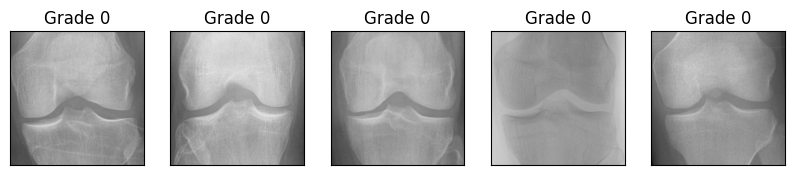

Train data (Balanced)-Doubtful


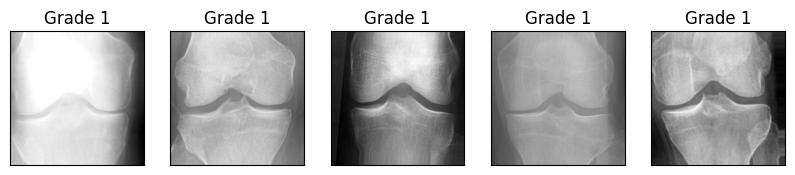

Train data (Balanced)-Minimal


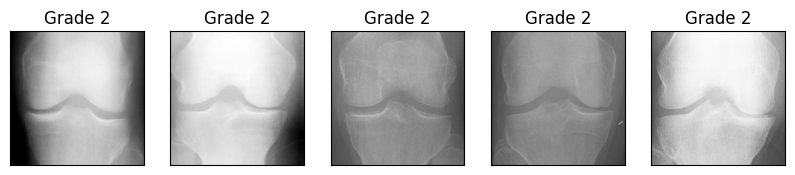

Train data (Balanced)-Moderate


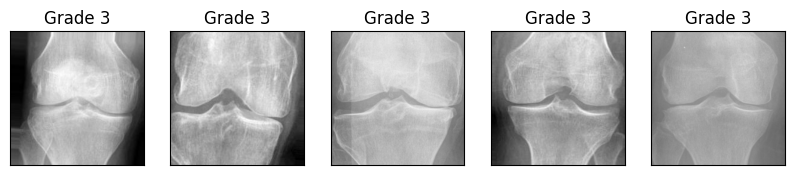

Train data (Balanced)-Severe


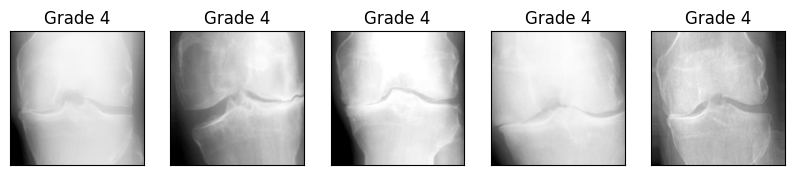

In [11]:
plot_classes(train_data, train_path, class_names, 'Train data (Balanced)')

Displaying sample images from the balanced training set to verify data quality.

## 3. Model Configuration

### Training Parameters
Define all hyperparameters and paths for the EfficientNet-V2B3 model. These settings have been optimized for balanced accuracy across all osteoarthritis severity grades.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — EfficientNet-V2B3 C1 (Baseline)
# ══════════════════════════════════════════════════════════════════════════════
MODEL_NAME = 'EfficientNet_V2B3_C1'
IMG_SIZE = 224
BATCH_SIZE = 4
EPOCHS = 50
EARLY_STOP_PATIENCE = 7

# Optimizer: Adam (default LR)
# Loss: Categorical Cross-Entropy
# Output: Dense(5, softmax)

# Architecture head: GAP → Dropout(0.2) → Dense(5, softmax)
DROPOUT_RATE = 0.2

ts = globals().get("target_size", (224, 224))
bs = globals().get("batch_size", 32)

# Data pipeline: ImageDataGenerator with no augmentation
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    # No preprocessing_function — no CLAHE
)

train_generator = datagen.flow_from_directory(
    train_path, class_mode='categorical', target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, shuffle=True,
)
valid_generator = datagen.flow_from_directory(
    valid_path, class_mode='categorical', target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, shuffle=False,
)

Found 11226 images belonging to 5 classes.
Found 826 images belonging to 5 classes.


### Loading Data into Generators
The generators load images in batches, resize them to 224×224 pixels, and apply CLAHE preprocessing for enhanced contrast.

In [15]:
y_train = train_generator.labels
y_val = valid_generator.labels

In [16]:
unique, counts = np.unique(y_train, return_counts=True)
print("Train: ", dict(zip(unique, counts)))

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
train_class_weights = dict(enumerate(class_weights))
print(train_class_weights)

Train:  {0: 2246, 1: 2245, 2: 2245, 3: 2245, 4: 2245}
{0: 0.9996438112199466, 1: 1.0000890868596881, 2: 1.0000890868596881, 3: 1.0000890868596881, 4: 1.0000890868596881}


## 5. Model Architecture

### Building the EfficientNet-V2B3 Model


In [ ]:
model = tf.keras.applications.efficientnet_v2.EfficientNetV2B3(
    input_shape=img_shape,
    include_top=False,
    weights="imagenet",
)

for layer in model.layers:
    layer.trainable = True

model_ft = tf.keras.models.Sequential(
    [
        model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(5, activation="softmax"),
    ]
)

model_ft.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b3 (Functio  (None, 7, 7, 1536)        12930622  
 nal)                                                            
                                                                 
 global_average_pooling2d (  (None, 1536)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1536)              0         
                                                                 
 dense (Dense)               (None, 5)                 7685      
                                                                 
Total params: 12938307 (49.36 MB)
Trainable params: 12829091 (48.94 MB)
Non-trainable params: 109216 (426.62 KB)
_________________________________________________________________


## 6. Model Training

### Training Process
The model trains for 20 epochs using the balanced training generator with class weights. Validation performance is monitored on a separate validation set.

In [19]:
model_ft.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

# Early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=save_model_ft,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

start_ft = timeit.default_timer()

history = model_ft.fit(
    train_generator,
    epochs=epochs,
    validation_data=valid_generator,
    class_weight=train_class_weights,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1,
)

stop_ft = timeit.default_timer()


Epoch 1/50


I0000 00:00:1780672527.184578   32049 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
E0000 00:00:1780672548.222798   32049 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/efficientnetv2-b3/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780672562.555504   32384 cuda_dnn.cc:461] Loaded cuDNN version 90701
I0000 00:00:1780672596.147413   32379 service.cc:153] XLA service 0x78601f6a2820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780672596.147449   32379 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.7.1)
I0000 00:00:1780672596.175717   32379 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780672596.297

702/702 [==============================] - ETA: 0s - loss: 0.9273 - accuracy: 0.6157
Epoch 1: val_loss improved from inf to 1.02981, saving model to models/model_EfficientNet-V2B3-Baseline_ft.keras
702/702 [==============================] - 214s 162ms/step - loss: 0.9273 - accuracy: 0.6157 - val_loss: 1.0298 - val_accuracy: 0.5581
Epoch 2/50
702/702 [==============================] - ETA: 0s - loss: 0.6910 - accuracy: 0.7127
Epoch 2: val_loss improved from 1.02981 to 0.99325, saving model to models/model_EfficientNet-V2B3-Baseline_ft.keras
702/702 [==============================] - 112s 159ms/step - loss: 0.6910 - accuracy: 0.7127 - val_loss: 0.9932 - val_accuracy: 0.6065
Epoch 3/50
702/702 [==============================] - ETA: 0s - loss: 0.6021 - accuracy: 0.7516
Epoch 3: val_loss improved from 0.99325 to 0.89684, saving model to models/model_EfficientNet-V2B3-Baseline_ft.keras
702/702 [==============================] - 111s 158ms/step - loss: 0.6021 - accuracy: 0.7516 - val_loss: 0

In [20]:
execution_time_ft = (stop_ft - start_ft) / 60
print(
    f"Model {model_name} fine tuning executed in {execution_time_ft:.2f} minutes"
)

Model EfficientNet-V2B3-Baseline fine tuning executed in 19.44 minutes


In [21]:
import json
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df.to_csv('train_history.csv', index=False)

with open('train_history.json', 'w', encoding='utf-8') as f:
    json.dump(history.history, f, indent=2)

print('Saved train_history.csv and train_history.json')

Saved train_history.csv and train_history.json


### Training History Visualization
Visualize training and validation curves to assess model convergence and detect overfitting.

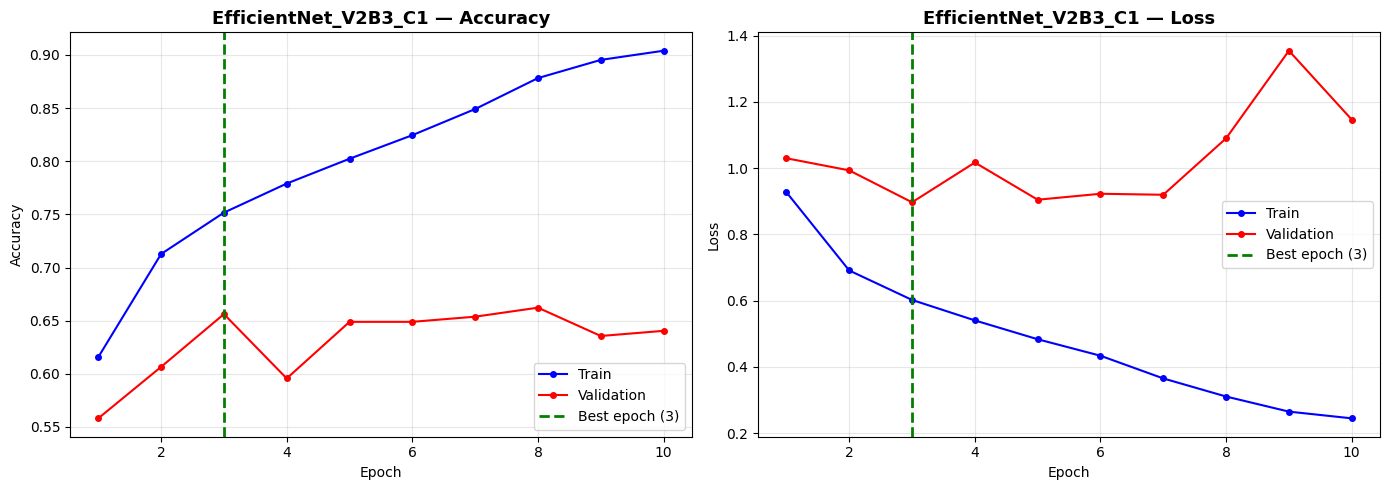

Total epochs: 10
Best epoch: 3 (lowest val_loss: 0.8968)
Best val_accuracy: 0.6562


In [4]:
# ── Training History Visualization — EfficientNet_V2B3 Baseline ──────────────
import json
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path.cwd().resolve()
report_dir = output_dir / 'reports'

MODEL_NAME = "EfficientNet_V2B3_C1"

with open(report_dir / 'train_history.json', 'r', encoding='utf-8') as f:
    history = json.load(f)

epochs = range(1, len(history['loss']) + 1)
has_accuracy = 'accuracy' in history
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if has_accuracy:
    ax1.plot(epochs, history['accuracy'], 'b-o', markersize=4, label='Train')
    ax1.plot(epochs, history['val_accuracy'], 'r-o', markersize=4, label='Validation')
    ax1.set_title(f'{MODEL_NAME} — Accuracy', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Accuracy')
else:
    ax1.plot(epochs, history['mae'], 'b-o', markersize=4, label='Train')
    ax1.plot(epochs, history['val_mae'], 'r-o', markersize=4, label='Validation')
    ax1.set_title(f'{MODEL_NAME} — MAE', fontsize=13, fontweight='bold')
    ax1.set_ylabel('MAE')

ax1.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

ax2.plot(epochs, history['loss'], 'b-o', markersize=4, label='Train')
ax2.plot(epochs, history['val_loss'], 'r-o', markersize=4, label='Validation')
ax2.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax2.set_title(f'{MODEL_NAME} — Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total epochs: {len(history["loss"])}')
print(f'Best epoch: {best_epoch} (lowest val_loss: {min(history["val_loss"]):.4f})')
if has_accuracy:
    print(f'Best val_accuracy: {history["val_accuracy"][best_epoch - 1]:.4f}')
else:
    print(f'Best val_mae: {history["val_mae"][best_epoch - 1]:.4f}')


In [22]:
model_ft.save(save_model_ft)
print(f"Model saved to {save_model_ft}")

Model saved to models/model_EfficientNet-V2B3-Baseline_ft.keras


### Saving the Trained Model
The trained model is saved for future inference and evaluation on new unseen X-ray images.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# EFFICIENTNET_V2B3_BASELINE — SETUP
# Categorical classification with softmax
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (precision_recall_fscore_support, roc_curve, auc, confusion_matrix)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

MODEL_NAME = "EfficientNet_V2B3_C1"
CLASS_NAMES = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']
NUM_CLASSES = 5
IMG_SIZE = 224
BATCH_SIZE = 16

output_dir = Path.cwd().resolve()
model_dir = output_dir / 'models'
report_dir = output_dir / 'reports'
best_model_path = model_dir / 'model_EfficientNet-V2B3-Baseline_ft.keras'

def find_dataset_dir():
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        for suffix in [('data', 'knee_osteoarthritis'), ('ml_workflow', 'data', 'knee_osteoarthritis'), ('Final_year_project', 'ml_workflow', 'data', 'knee_osteoarthritis')]:
            candidate = root.joinpath(*suffix)
            if candidate.exists():
                return candidate.resolve()
    raise FileNotFoundError('Dataset directory not found')

BASE_DIR = find_dataset_dir()
VALID_PATH = BASE_DIR / 'val'
TEST_PATH = BASE_DIR / 'test'

# No preprocessing function — just rescaling (same as training)
datagen = ImageDataGenerator()
valid_generator = datagen.flow_from_directory(VALID_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False)
test_generator = datagen.flow_from_directory(TEST_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False)

# Load model
best_model = tf.keras.models.load_model(str(best_model_path))
print('Loaded model from:', best_model_path)

# Load CSV metrics
val_csv = pd.read_csv(report_dir / 'metrics_validation.csv')
test_csv = pd.read_csv(report_dir / 'metrics_test.csv')

# ── Helpers ──────────────────────────────────────────────────────────────────
def display_full_metrics(csv_row, y_true, pred_labels, model_name, split_name):
    sep = '=' * 72
    sep2 = '-' * 72
    print(f'\n{sep}')
    print(f'  COMPREHENSIVE EVALUATION METRICS MATRIX')
    print(f'  Model : {model_name}')
    print(f'  Split : {split_name}')
    print(f'{sep}')
    print(f'  {"Metric":<44} {"Value":>10}')
    print(f'  {sep2}')
    print(f'  {"Overall Accuracy":<44} {csv_row["Overall Accuracy"]:>10.4f}')
    print(f'  {"Balanced Accuracy":<44} {csv_row["Balanced Accuracy"]:>10.4f}')
    print(f'  {"Mean Absolute Error (MAE)":<44} {csv_row["MAE"]:>10.4f}')
    print(f'  {"Macro ROC AUC (ordinal matrix)":<44} {csv_row["Macro ROC AUC (ordinal)"]:>10.4f}')
    print(f'  {"Quadratic Weighted Kappa (QWK)":<44} {csv_row["Quadratic Weighted Kappa"]:>10.4f}')
    print(f'{sep}')
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, pred_labels, labels=range(NUM_CLASSES), zero_division=0)
    print(f'\n  PER-CLASS BREAKDOWN')
    print(f'  {sep2}')
    print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
    print(f'  {sep2}')
    for i, c in enumerate(CLASS_NAMES):
        print(f'  {c:<14} {prec[i]:>10.4f} {rec[i]:>10.4f} {f1[i]:>10.4f} {int(sup[i]):>10}')
    print(f'  {sep2}')
    total = int(np.sum(sup))
    print(f'  {"accuracy":<14} {"":>10} {"":>10} {csv_row["Overall Accuracy"]:>10.4f} {total:>10}')
    print(f'  {"macro avg":<14} {np.mean(prec):>10.4f} {np.mean(rec):>10.4f} {np.mean(f1):>10.4f} {total:>10}')
    print(f'  {"weighted avg":<14} {np.average(prec,weights=sup):>10.4f} {np.average(rec,weights=sup):>10.4f} {np.average(f1,weights=sup):>10.4f} {total:>10}')
    print(f'  {sep2}\n')

def plot_roc(y_true, probs, title):
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    plt.figure(figsize=(10, 7))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, lw=2, label=f'{CLASS_NAMES[i]} (AUC={auc(fpr,tpr):.4f})')
    plt.plot([0,1],[0,1],'k--',lw=2)
    plt.xlim([0,1]); plt.ylim([0,1.05])
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(title)
    plt.legend(loc='lower right'); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_f1(y_true, pred_labels, title):
    _, _, f1, _ = precision_recall_fscore_support(y_true, pred_labels, labels=range(NUM_CLASSES), zero_division=0)
    plt.figure(figsize=(8, 5))
    bars = plt.bar(CLASS_NAMES, f1, color='steelblue', edgecolor='black')
    for b, v in zip(bars, f1):
        plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}', ha='center')
    plt.ylim(0, 1.0); plt.ylabel('F1 Score'); plt.title(title)
    plt.tight_layout(); plt.show()

def plot_cm(y_true, pred_labels, title, normalize=False):
    cm = confusion_matrix(y_true, pred_labels, labels=range(NUM_CLASSES))
    if normalize: cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(title); plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

print('Setup complete.')


I0000 00:00:1783519093.511213  134946 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.


W0000 00:00:1783519130.790973  134946 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1783519130.795893  134946 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1783519131.343177  134946 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5263 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050, pci bus id: 0000:06:00.0, compute capability: 12.0a


Loaded model from: /workspaces/fyp_experiment/Final_year_project/ml_workflow/training/knee_osteoarthritis/EfficientNet_V2B3/EfficientNet_V2B3 (Baseline)/models/model_EfficientNet-V2B3-Baseline_ft.keras
Setup complete.


## 7. Validation Evaluation

### Performance on Validation Set
Evaluating the model's performance on the held-out validation set using loss and accuracy metrics.

I0000 00:00:1783519631.377993  134946 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1783519642.602836  139491 cuda_dnn.cc:461] Loaded cuDNN version 90701


52/52 [==============================] - 37s 136ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : EfficientNet_V2B3_C1
  Split : Validation
  Metric                                            Value
  ------------------------------------------------------------------------
  Overall Accuracy                                 0.6562
  Balanced Accuracy                                0.6283
  Mean Absolute Error (MAE)                        0.4649
  Macro ROC AUC (ordinal matrix)                   0.9358
  Quadratic Weighted Kappa (QWK)                   0.7660

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.6253     0.9512     0.7545        328
  Doubtful           0.5769     0.0980     0.1676        153
  Minimal            0.6576     0.5708     0.6111        212
  Moderat

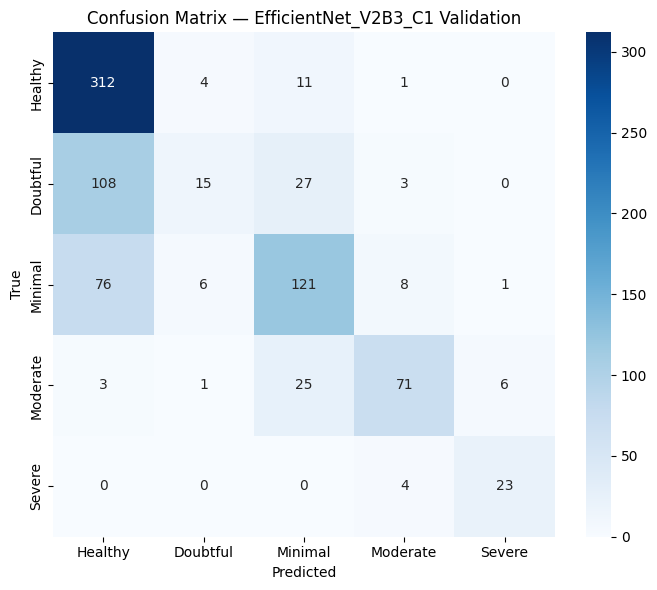

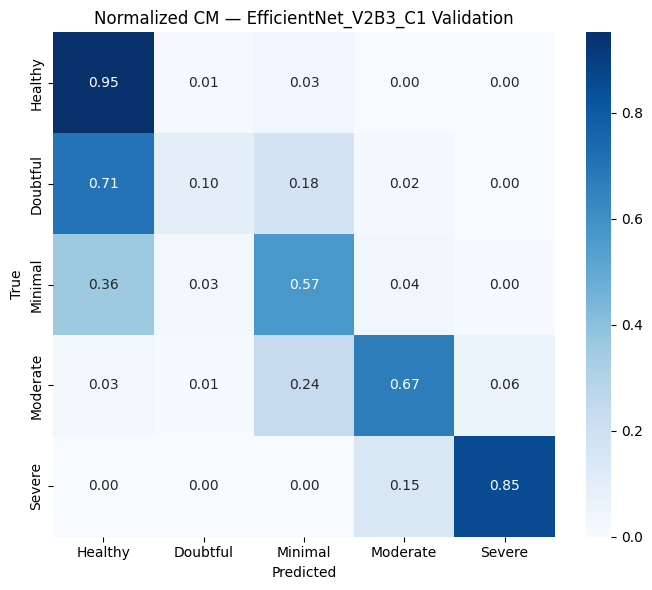

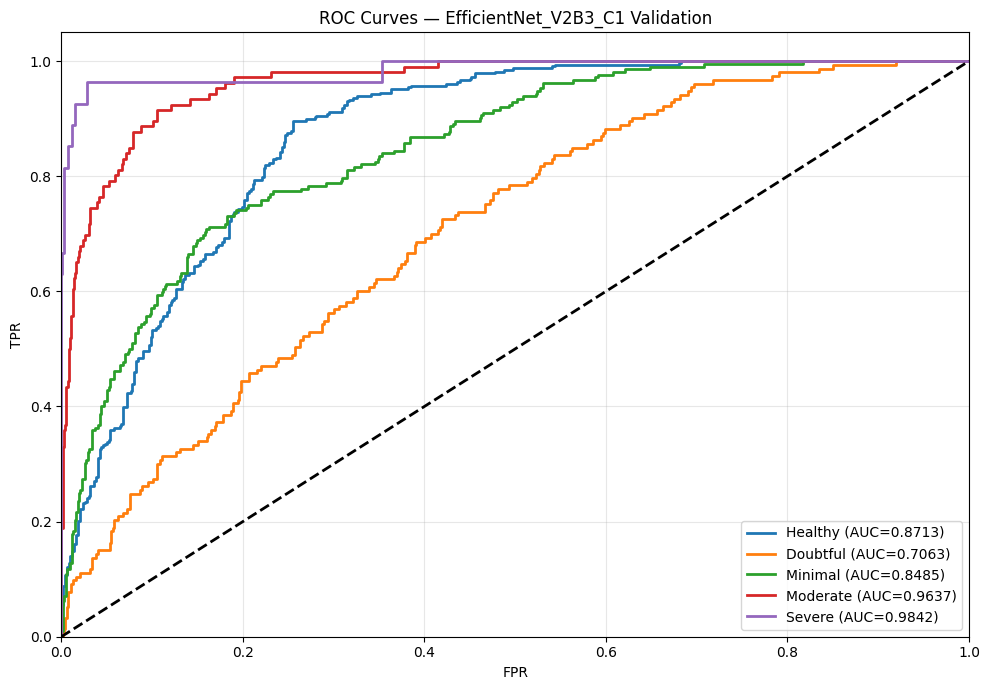

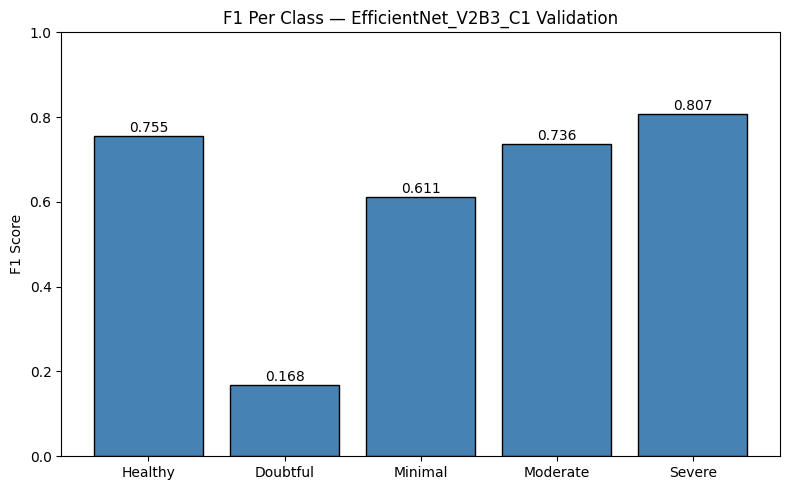

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# VALIDATION
# ══════════════════════════════════════════════════════════════════════════════
valid_generator.reset()
val_probs = best_model.predict(valid_generator, verbose=1)
val_true = valid_generator.labels
val_pred_labels = np.argmax(val_probs, axis=1)

display_full_metrics(val_csv.iloc[0], val_true, val_pred_labels, MODEL_NAME, 'Validation')
plot_cm(val_true, val_pred_labels, f'Confusion Matrix — {MODEL_NAME} Validation', normalize=False)
plot_cm(val_true, val_pred_labels, f'Normalized CM — {MODEL_NAME} Validation', normalize=True)
plot_roc(val_true, val_probs, f'ROC Curves — {MODEL_NAME} Validation')
plot_f1(val_true, val_pred_labels, f'F1 Per Class — {MODEL_NAME} Validation')


## 8. Test Set Evaluation

### Preparing Test Data
Loading the independent test set that was not used during training or validation to assess true model generalization.

In [29]:
y_test = test_generator.labels

In [30]:
EfficientNet = tf.keras.models.load_model(save_model_ft)

### Loading the Saved Model
Reloading the trained model from disk to evaluate on the test set.

In [31]:
predictions_EfficientNet = EfficientNet.predict(test_generator)
score_EfficientNet=EfficientNet.evaluate(test_generator, verbose=1)
print('Test loss:', score_EfficientNet[0])
print('Test acc:', score_EfficientNet[1])

104/104 [==============================] - 7s 40ms/step - loss: 0.8050 - accuracy: 0.6661
Test loss: 0.8049871921539307
Test acc: 0.6660627722740173


Found 1656 images belonging to 5 classes.
104/104 [==============================] - 11s 104ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : EfficientNet_V2B3_C1
  Split : Test
  Metric                                            Value
  ------------------------------------------------------------------------
  Overall Accuracy                                 0.6661
  Balanced Accuracy                                0.6449
  Mean Absolute Error (MAE)                        0.4390
  Macro ROC AUC (ordinal matrix)                   0.9501
  Quadratic Weighted Kappa (QWK)                   0.7892

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.6185     0.9640     0.7535        639
  Doubtful           0.2000     0.0270     0.0476        296
  Minimal            0.7179     

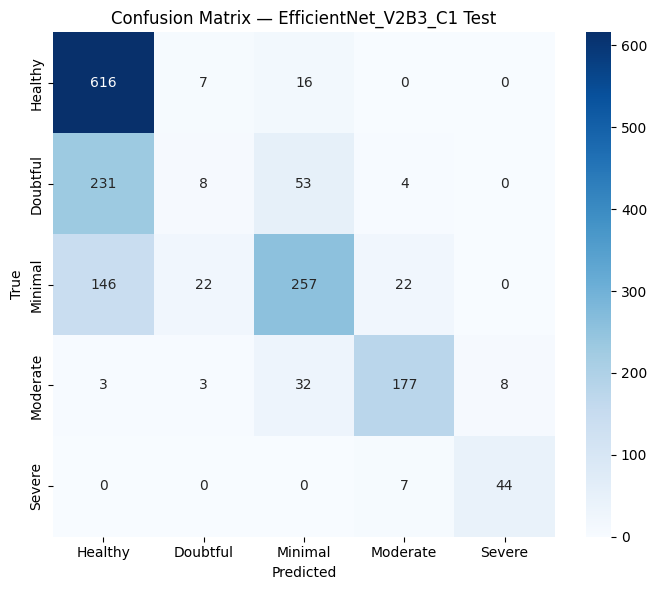

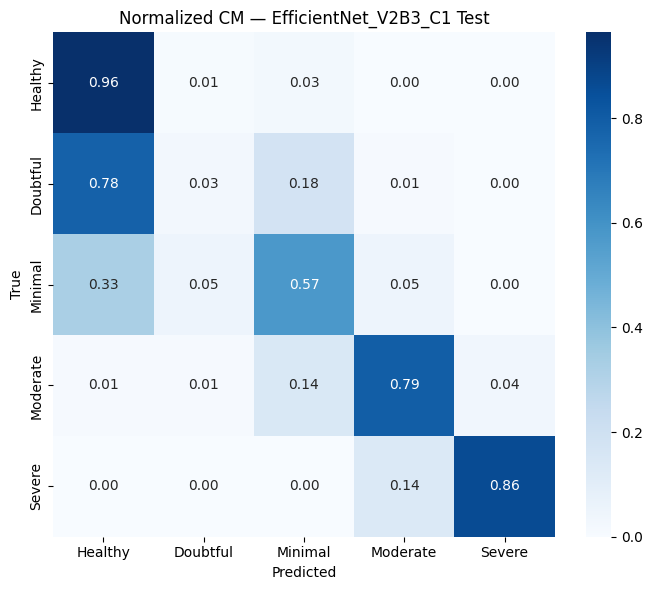

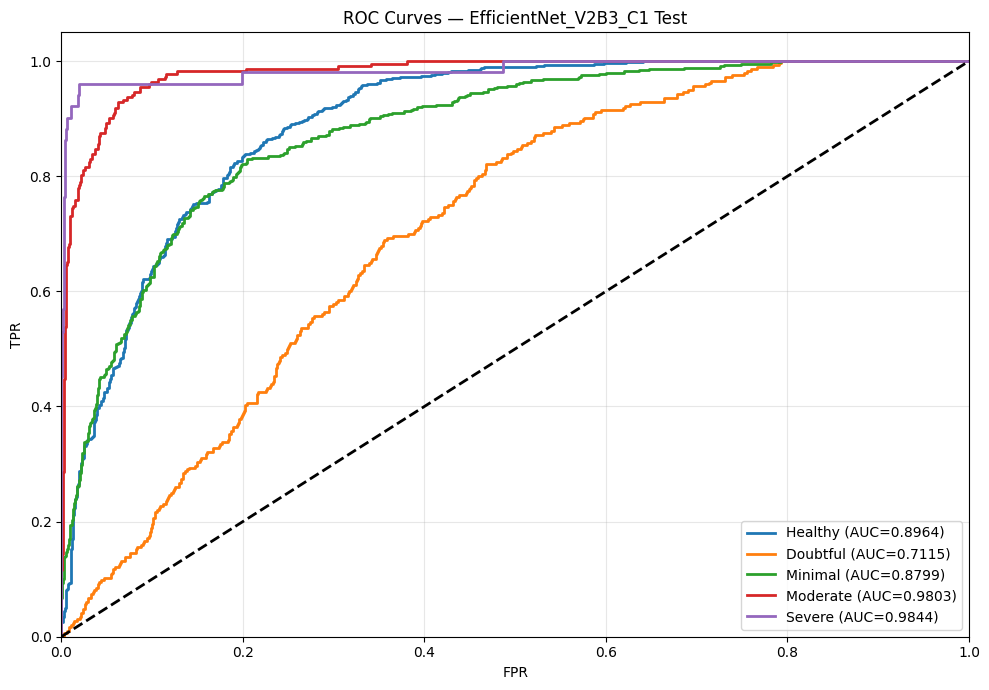

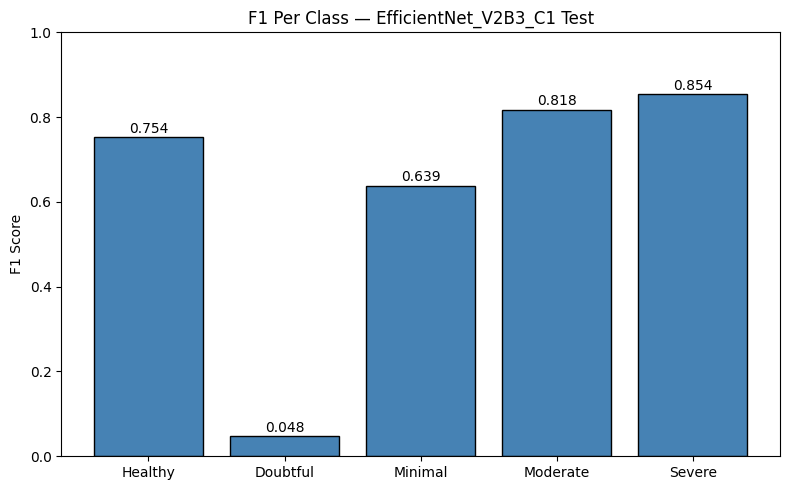

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# TEST
# ══════════════════════════════════════════════════════════════════════════════
test_generator = datagen.flow_from_directory(TEST_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False)
test_probs = best_model.predict(test_generator, verbose=1)
test_true = test_generator.labels
test_pred_labels = np.argmax(test_probs, axis=1)

display_full_metrics(test_csv.iloc[0], test_true, test_pred_labels, MODEL_NAME, 'Test')
plot_cm(test_true, test_pred_labels, f'Confusion Matrix — {MODEL_NAME} Test', normalize=False)
plot_cm(test_true, test_pred_labels, f'Normalized CM — {MODEL_NAME} Test', normalize=True)
plot_roc(test_true, test_probs, f'ROC Curves — {MODEL_NAME} Test')
plot_f1(test_true, test_pred_labels, f'F1 Per Class — {MODEL_NAME} Test')


## 10. Model Interpretability & Visualization

### GradCAM Functions
These functions generate heatmaps showing which regions of each X-ray the model focuses on when making predictions. This helps validate that the model is identifying clinically relevant features associated with osteoarthritis.

In [34]:
def make_gradcam_heatmap(grad_model, img_array, pred_index=None):
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def save_and_display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)

    jet = cm.get_cmap("jet")

    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(
        superimposed_img
    )

    return superimposed_img

In [35]:
tests_data = get_classes(test_path, class_names, 'test')

----test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%


### Preparing GradCAM
Setting up the gradient model to extract feature map activations from the final convolutional layer before the classification head.

In [36]:
# Last layer
conv_output = EfficientNet.get_layer("global_average_pooling2d").input

grad_model = tf.keras.models.Model(
    [EfficientNet.inputs], [conv_output, EfficientNet.output]
)

# model
EfficientNet.layers[-1].activation = None

Test data - Healthy


/tmp/ipykernel_32049/3638193015.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


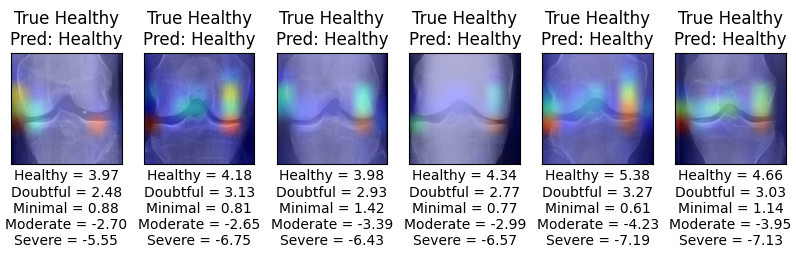

Test data - Doubtful


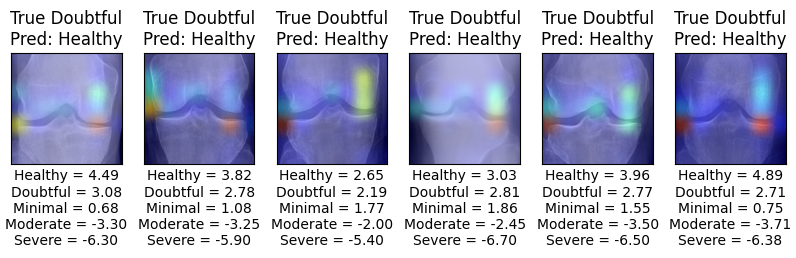

Test data - Minimal


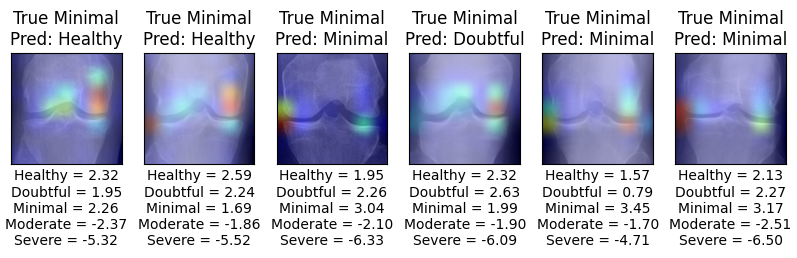

Test data - Moderate


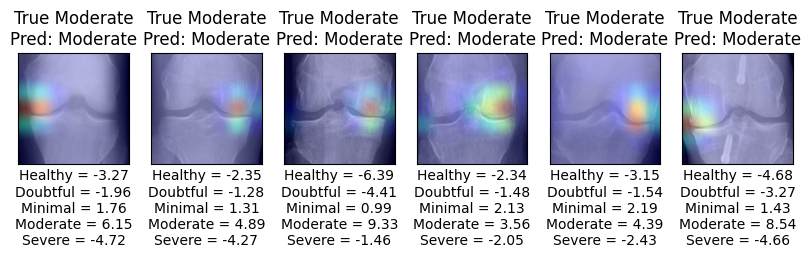

Test data - Severe


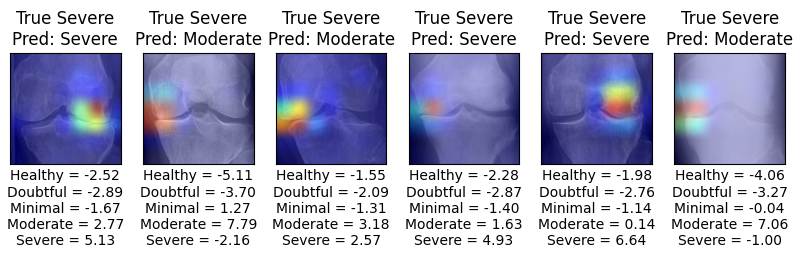

In [37]:
for k, v in tests_data.items():
    print(f"Test data - {class_names[k]}")
    plt.figure(figsize=(10, 28))
    for i in range(6):
        img_path = os.path.join(test_path, str(k), v[i])
        # prepare image
        img = tf.keras.preprocessing.image.load_img(
            img_path, target_size=target_size
        )
        img = tf.keras.preprocessing.image.img_to_array(img)

        img_aux = img.copy()
        img_array = np.expand_dims(img_aux, axis=0)
        img_array = np.float32(img_array)
        img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)

        y_pred = EfficientNet.predict(img_array, verbose=0)[0]

        heatmap = make_gradcam_heatmap(grad_model, img_array)
        image = save_and_display_gradcam(img, heatmap)

        plt.subplot(1, 6, 1 + i, xticks=[], yticks=[])
        plt.imshow(image)
        plt.title(
            f"True {class_names[k]}\nPred: {class_names[np.argmax(y_pred)]}"
        )
        plt.xlabel(
            "\n".join([f"{c} = {p:.2f}" for c, p in zip(class_names, y_pred)])
        )
    plt.show()

### GradCAM Visualization on Test Samples
For each class, displaying 6 representative test images with their GradCAM heatmaps overlaid. The heatmap highlights regions the model uses for classification decisions. Warmer colors (red/yellow) indicate higher model attention.